In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization, Bidirectional








In [4]:
# Load and preprocess data
df = pd.read_csv('generated_new.csv')
df.dropna(inplace=True)

# Feature Engineering

# Extract minutes from Time (HH:MM)
df['Minutes'] = pd.to_datetime(df['Time'], format='%H:%M', errors='coerce').dt.hour * 60 + \
                pd.to_datetime(df['Time'], format='%H:%M', errors='coerce').dt.minute

# Extract hour from Minutes
df['Hour'] = df['Minutes'] // 60

# Is weekend (binary: 1 for weekend, 0 for weekday)
df['Is_Weekend'] = (pd.to_datetime(df['Time'], format='%H:%M').dt.weekday >= 5).astype(int)

# Add interaction terms
df['Temp_Humidity'] = df['Temp'] * df['Humidity']
df['Light_Occupancy'] = df['Light_Intensity'] * df['Occupancy']
df['Temp_Light'] = df['Temp'] * df['Light_Intensity']
df['Temp_Occupancy'] = df['Temp'] * df['Occupancy']
df['Humidity_Light'] = df['Humidity'] * df['Light_Intensity']

# Lag features (energy consumption, temperature, and humidity)
df['Energy_Lag1'] = df['Energy'].shift(1)
df['Temp_Lag1'] = df['Temp'].shift(1)
df['Humidity_Lag1'] = df['Humidity'].shift(1)
df['Light_Lag1'] = df['Light_Intensity'].shift(1)
df['Occupancy_Lag1'] = df['Occupancy'].shift(1)

# Remove the first row which has NaN after lagging
df.dropna(inplace=True)

# One-hot encode Day of the week (categorical feature)
df = pd.get_dummies(df, columns=['Day'], drop_first=True)


In [5]:
# Define features and target
features = ['Minutes', 'Temp', 'Humidity', 'Light_Intensity', 'Occupancy', 'Temp_Humidity', 'Light_Occupancy',
            'Temp_Light', 'Temp_Occupancy', 'Humidity_Light', 'Is_Weekend', 'Energy_Lag1', 'Temp_Lag1', 'Humidity_Lag1',
            'Light_Lag1', 'Occupancy_Lag1'] + [col for col in df.columns if col.startswith('Day_')]

X = df[features].values
y = df['Energy'].values

# Scale data
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()
X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y.reshape(-1, 1))

# Create sequences for LSTM
def create_sequences(X, y, seq_length):
    X_seq, y_seq = [], []
    for i in range(len(X) - seq_length):
        X_seq.append(X[i:i + seq_length])
        y_seq.append(y[i + seq_length])
    return np.array(X_seq), np.array(y_seq)

seq_length = 15  # Temporal dependency window
X_seq, y_seq = create_sequences(X_scaled, y_scaled, seq_length)

In [6]:
# Train/test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_seq, y_seq, test_size=0.2, random_state=42)

# Build the optimized LSTM model
def build_optimized_model(input_shape):
    model = Sequential([
        Bidirectional(LSTM(128, activation='tanh', return_sequences=True), input_shape=input_shape),
        Dropout(0.3),
        BatchNormalization(),
        LSTM(64, activation='tanh', return_sequences=False),
        Dropout(0.3),
        Dense(64, activation='relu'),
        Dense(1)  # Output for energy prediction
    ])
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss='mse', metrics=['mae'])
    return model

model = build_optimized_model((seq_length, X_train.shape[2]))


/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [7]:

# Train model with early stopping
from tensorflow.keras.callbacks import EarlyStopping
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=200,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1
)

# Get predictions
y_pred_scaled = model.predict(X_test, verbose=0)
y_test_actual = scaler_y.inverse_transform(y_test.reshape(-1, 1))
y_pred = scaler_y.inverse_transform(y_pred_scaled)


Epoch 1/200
240/240 ━━━━━━━━━━━━━━━━━━━━ 24s 81ms/step - loss: 0.0747 - mae: 0.1656 - val_loss: 0.0118 - val_mae: 0.0849
Epoch 2/200
240/240 ━━━━━━━━━━━━━━━━━━━━ 17s 71ms/step - loss: 0.0097 - mae: 0.0753 - val_loss: 0.0074 - val_mae: 0.0684
Epoch 3/200
240/240 ━━━━━━━━━━━━━━━━━━━━ 20s 70ms/step - loss: 0.0076 - mae: 0.0668 - val_loss: 0.0085 - val_mae: 0.0687
Epoch 4/200
240/240 ━━━━━━━━━━━━━━━━━━━━ 17s 72ms/step - loss: 0.0062 - mae: 0.0599 - val_loss: 0.0035 - val_mae: 0.0444
Epoch 5/200
240/240 ━━━━━━━━━━━━━━━━━━━━ 20s 71ms/step - loss: 0.0049 - mae: 0.0538 - val_loss: 0.0048 - val_mae: 0.0523
Epoch 6/200
240/240 ━━━━━━━━━━━━━━━━━━━━ 21s 71ms/step - loss: 0.0044 - mae: 0.0505 - val_loss: 0.0031 - val_mae: 0.0435
Epoch 7/200
240/240 ━━━━━━━━━━━━━━━━━━━━ 20s 71ms/step - loss: 0.0042 - mae: 0.0494 - val_loss: 0.0032 - val_mae: 0.0455
Epoch 8/200
240/240 ━━━━━━━━━━━━━━━━━━━━ 20s 71ms/step - loss: 0.0038 - mae: 0.0473 - val_loss: 0.0024 - val_mae: 0.0381
Epoch 9/200
240/240 ━━━━━━━━━━━━

In [8]:
# Evaluate metrics
rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred))
mae = mean_absolute_error(y_test_actual, y_pred)
r2 = r2_score(y_test_actual, y_pred)
mape = np.mean(np.abs((y_test_actual - y_pred) / y_test_actual)) * 100

print("\nModel Performance:")
print(f"Root Mean Square Error (RMSE): {rmse:.3f}")
print(f"Mean Absolute Error (MAE): {mae:.3f} kWh")
print(f"R-squared Score: {r2:.3f}")
print(f"Mean Absolute Percentage Error (MAPE): {mape:.2f}%")



Model Performance:
Root Mean Square Error (RMSE): 0.548
Mean Absolute Error (MAE): 0.413 kWh
R-squared Score: 0.947
Mean Absolute Percentage Error (MAPE): 5.69%


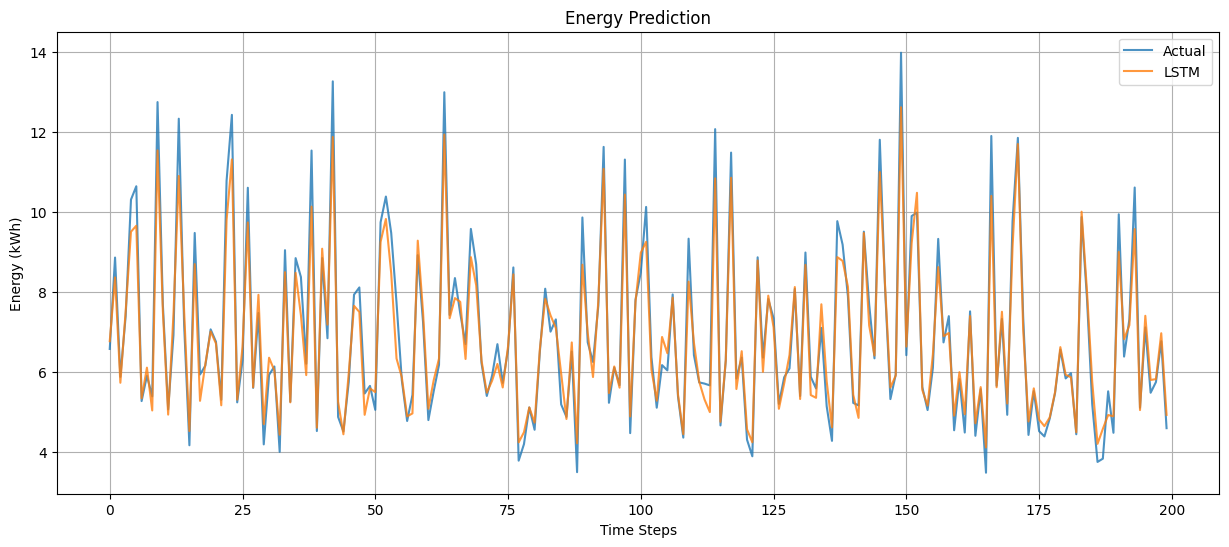

In [10]:
# Plot predictions
def plot_predictions(y_test_actual, y_pred, num_points=200):
    plt.figure(figsize=(15, 6))
    plt.plot(y_test_actual[:num_points], label='Actual', alpha=0.8)
    plt.plot(y_pred[:num_points], label='LSTM', alpha=0.8)
    plt.title('Energy Prediction')
    plt.xlabel('Time Steps')
    plt.ylabel('Energy (kWh)')
    plt.legend()
    plt.grid(True)
    plt.show()

plot_predictions(y_test_actual, y_pred)
